In [1]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import sys
from pystac_client import Client
import requests
import fsspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
#from eumdac import AccessToken, DataStore#?????

In [2]:
%pip install s3fs

  Using cached s3fs-2026.3.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached aiobotocore-3.5.0-py3-none-any.whl.metadata (27 kB)
  Using cached aioitertools-0.13.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached botocore-1.42.91-py3-none-any.whl.metadata (5.9 kB)
  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached wrapt-2.1.2-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
Using cached s3fs-2026.3.0-py3-none-any.whl (32 kB)
Using cached aiobotocore-3.5.0-py3-none-any.whl (88 kB)
Using cached aioitertools-0.13.0-py3-none-any.whl (24 kB)
Using cached botocore-1.42.91-py3-none-any.whl (14.9 MB)
Using cached jmespath-1.1.0-py3-none-any.whl (20 kB)
Using cached wrapt-2.1.2-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl (121 kB)
Note: you may need to restart the kernel to use updated packages.


definitions

In [3]:
CREDENTIALS_FILE = Path("credentials.txt")
def _load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with file_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds
# --- ESA MAAP API ---
def get_earthcare_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = _load_credentials()

    offline_token = creds.get("OFFLINE_TOKEN")
    client_id = creds.get("CLIENT_ID")
    client_secret = creds.get("CLIENT_SECRET")

    if not all([offline_token, client_id, client_secret]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": client_id,
        "client_secret": client_secret,
        "grant_type": "refresh_token",
        "refresh_token": offline_token,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

lightning data

In [4]:
# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

In [5]:
selected_file = 'EC_lightning_clusters.parquet'
#earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    #filters=[('earthcare_id', "==", earthcare_id)],
)
#gdf

In [6]:
gdf = gdf.sort_values('peak_datetime')

## Identification of possition

this is when LI and GLM are directly tandem

set id, search for correct clusters

In [7]:
earthcare_id = "07799H"

In [8]:
unique_id_1 = gdf.loc[(gdf["earthcare_id"] == earthcare_id) & (gdf["source"] == "LI")].unique_id.iloc[0]
unique_id_2 = gdf.loc[(gdf["earthcare_id"] == earthcare_id) & (gdf["source"] == "GLM")].unique_id.iloc[0]
row_1 = gdf.loc[gdf["unique_id"] == unique_id_1].iloc[0]
row_2 = gdf.loc[gdf["unique_id"] == unique_id_2].iloc[0]
source_1 = row_1.source
source_2 = row_2.source
earthcare_id = row_1["earthcare_id"]
orbit_number = int(row_1["earthcare_id"][:-1])
frame = row_1["earthcare_id"][-1]
cluster_id = row_1["cluster_id"]
peak_lat = row_1["peak_lat"]
peak_lon = row_1["peak_lon"]

The most timeconsuming part, autentication and loading EarthCARE data

In [9]:
# --- Authentication ---
# This notebook uses helper functions from lightning2ec.
# If working outside the repository, copy the required functions into the notebook.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
#from lightning2ec.token_handling import get_earthcare_token
token = get_earthcare_token()
fs_headers = {"Authorization": f"Bearer {token}"}


msi_product_type = "MSI_RGR_1C"
cpr_product_type = "CPR_FMR_2A"
ec_collections = ['EarthCAREL2Products_MAAP', 'EarthCAREL0L1Products_MAAP']
catalog_url = "https://catalog.maap.eo.esa.int/catalogue/"
catalog = Client.open(catalog_url)
fs = fsspec.filesystem("https", headers=fs_headers)

def search_earthcare_product(catalog, collections, orbit_number, frame, product_type, max_items=1):
    search = catalog.search(
        collections=collections,
        filter=(
            f"frame = '{frame}' and "
            f"orbitNumber = {orbit_number:05d} and "
            f"productType = '{product_type}'"
        ),
        method="GET",
        max_items=max_items,
    )
    items = list(search.items())
    if not items:
        raise ValueError(
            f"No EarthCARE product found for orbit {orbit_number:05d}, "
            f"frame {frame}, productType {product_type}."
        )
    return items[0].assets["enclosure_h5"].href


msi_href = search_earthcare_product(catalog=catalog, collections=ec_collections, orbit_number=orbit_number, frame=frame, product_type=msi_product_type,)
cpr_href = search_earthcare_product(catalog=catalog, collections=ec_collections, orbit_number=orbit_number, frame=frame, product_type=cpr_product_type,)

with fs.open(msi_href, "rb") as f:
    ds_msi = xr.open_dataset(f, engine="h5netcdf", group="ScienceData").load()

with fs.open(cpr_href, "rb") as f:
    ds_cpr = xr.open_dataset(f, engine="h5netcdf", group="ScienceData").load()

Loading the lightning data

In [10]:
year = str(row_1.peak_datetime.year)
month = str(row_1.peak_datetime.month)

lightning_file_1 = 'EC_lightning_' + source_1 + '_' + year + '_' + month + '.parquet'

lightning_gdf_1 = gpd.read_parquet(
    f"{bucket}{prefix}{lightning_file_1}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    filters=[('earthcare_id', "==", earthcare_id)],
)

lightning_file_2 = 'EC_lightning_' + source_2 + '_' + year + '_' + month + '.parquet'

lightning_gdf_2 = gpd.read_parquet(
    f"{bucket}{prefix}{lightning_file_2}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    filters=[('earthcare_id', "==", earthcare_id)],
)

Plotting

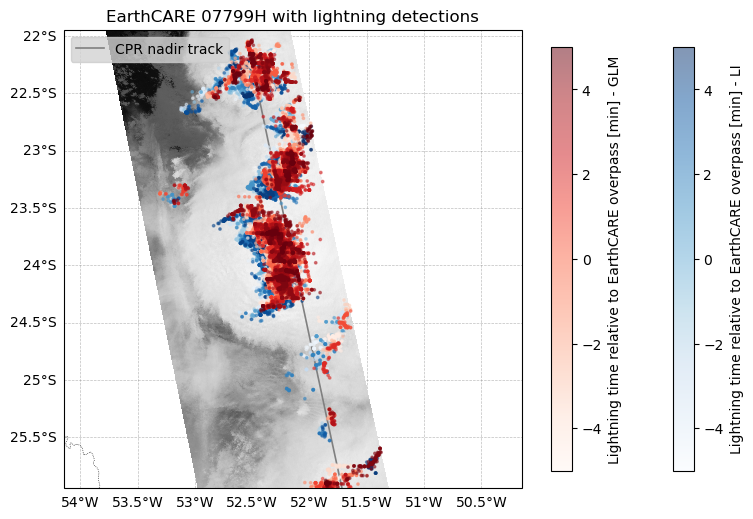

In [11]:
# --- MSI background ---
band = ds_msi["pixel_values"].sel(band='TIR2').values # 10.8 µm (VIS, VNIR, SWIR1, SWIR2, TIR1, TIR2, TIR3)
lat_msi = ds_msi["latitude"].values
lon_msi = ds_msi["longitude"].values
nodata = band.max()
valid = band < nodata
row_mask = valid.any(axis=1)
col_mask = valid[row_mask].any(axis=0)
band_clipped, lat_clipped, lon_clipped = [arr[np.ix_(row_mask, col_mask)] for arr in (band, lat_msi, lon_msi)]

# --- CPR track ---
lat_cpr = ds_cpr["latitude"].values
lon_cpr = ds_cpr["longitude"].values
valid_cpr = np.isfinite(lat_cpr) & np.isfinite(lon_cpr)


# --- Lightning data ---
lightning_gdf_1 = lightning_gdf_1.sort_values("ec_time_diff", ascending=True)
lon_li_1 = lightning_gdf_1.parallax_corrected_lon.to_numpy()
lat_li_1 = lightning_gdf_1.parallax_corrected_lat.to_numpy()
time_li_1 = lightning_gdf_1["ec_time_diff"] / np.timedelta64(1, "m")
valid_li_1 = np.isfinite(lon_li_1) & np.isfinite(lat_li_1) & np.isfinite(time_li_1)

lightning_gdf_2 = lightning_gdf_2.sort_values("ec_time_diff", ascending=True)
lon_li_2 = lightning_gdf_2.geometry.x.to_numpy()
lat_li_2 = lightning_gdf_2.geometry.y.to_numpy()
time_li_2 = lightning_gdf_2["ec_time_diff"] / np.timedelta64(1, "m")
valid_li_2 = np.isfinite(lon_li_2) & np.isfinite(lat_li_2) & np.isfinite(time_li_2)

# --- Plot ---
half_width = 2.0 #change it if you want
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
#ceurope_bbox = box(8, 44, 20, 55) -> (lon min, lat min, lon max, lat max)
bbox = box(peak_lon - half_width, peak_lat - half_width, peak_lon + half_width, peak_lat + half_width)
minx, miny, maxx, maxy = bbox.bounds
ax.set_extent([minx, maxx, miny, maxy], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--",)
gl.top_labels = False
gl.right_labels = False

vmin = band_clipped.min()
vmax = band_clipped[band_clipped < 9999].max()
ax.pcolormesh(lon_clipped, lat_clipped, band_clipped, cmap="Greys", transform=proj, zorder=2, vmin = vmin, vmax=vmax)
ax.plot(lon_cpr[valid_cpr], lat_cpr[valid_cpr], color="grey", linewidth=1.2, transform=proj, label="CPR nadir track", zorder=3,)
sc_1 = ax.scatter(lon_li_1[valid_li_1], lat_li_1[valid_li_1], c=time_li_1[valid_li_1], cmap="Blues", s=3, transform=proj, zorder=4, alpha=0.5)
sc_2 = ax.scatter(lon_li_2[valid_li_2], lat_li_2[valid_li_2], c=time_li_2[valid_li_2], cmap="Reds", s=3, transform=proj, zorder=4, alpha=0.5)
cbar_1 = plt.colorbar(sc_1, ax=ax, shrink=0.55)
cbar_2 = plt.colorbar(sc_2, ax=ax, shrink=0.55)
cbar_1.set_label("Lightning time relative to EarthCARE overpass [min] - LI")
cbar_2.set_label("Lightning time relative to EarthCARE overpass [min] - GLM")

ax.set_title(f"EarthCARE {earthcare_id} with lightning detections")
ax.legend(loc="upper left", facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=5)

plt.tight_layout()
plt.show()
#fig.savefig("img_comp_LI_GLM_" + str(earthcare_id) + ".png" )